In [ ]:
import os
import glob
import pandas as pd
from tqdm import tqdm

input_dir = "./outputs/harmonization/"

search_pattern = os.path.join(input_dir, "**", "*radiomics.csv")
csv_files = glob.glob(search_pattern, recursive=True)

assert csv_files, "Aucun fichier CSV de radiomiques trouvé dans le répertoire spécifié."
    
print(f"📄 {len(csv_files)} fichiers trouvés. Début de la lecture...")

df_list = []
for file_path in tqdm(csv_files, desc="Lecture ..."):
    df = pd.read_csv(file_path)
    
    if df.empty: 
        continue
    
    parts = os.path.normpath(file_path).split(os.sep)
    
    # structure du dossier output que j'ai préalablement définie
    if len(parts) >= 4:
        domain = parts[ -4 ]
        
        if "_to_" in domain: # stargan
            domain_source, domain_target = domain.split("_to_", 1)
        else: # harmonisation std
            domain_source, domain_target = domain, None
            
        # Insertion des métadonnées contextuelles au début du DataFrame
        df.insert(0, 'Domain_Target', domain_target)
        df.insert(0, 'Domain_Source', domain_source)
        df.insert(0, 'Domain', domain)
    else:
        df.insert(0, 'Source_Path', os.path.dirname(file_path))
    
    df_list.append(df)
        

assert df_list, "Aucun DataFrame valide n'a été créé à partir des fichiers CSV"

print("🔗 Concaténation des DataFrames...")
master_df = pd.concat(df_list, ignore_index=True)

print("="*50)
print("✅ FUSION TERMINÉE AVEC SUCCÈS")
print("="*50)
print(f"Total des lignes  : {len(master_df)}")
print(f"Total des colonnes: {len(master_df.columns)}")
print("="*50)

# master_df.head()

save_path = 'data/master_radiomics.csv'
master_df.to_csv(save_path, index=False)
print(f"💾 DataFrame fusionné sauvegardé sous : {save_path}")

In [7]:
# read csv
import pandas as pd
master_df = pd.read_csv('./master_radiomics.csv')
master_df

,Domain,Domain_Source,Domain_Target,Subject_ID,VOI,Component,Modality,Image_Filename,ROI_type,original_firstorder_10Percentile,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,curie,curie,NaN,2077,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,1.918541,...,5.158041,0.054021,0.026286,0.857736,0.001630,5.921439,0.003189,20.221136,0.025901,0.103394
1,curie,curie,NaN,2089,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,3.767481,...,9.542391,0.079232,0.018221,0.539289,0.001297,5.396629,0.004347,15.440477,0.026623,0.144993
2,curie,curie,NaN,2055,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,1.436280,...,36.793217,0.128431,0.008917,0.095788,0.001280,23.780950,0.002498,2.929520,0.013339,0.020916
3,curie,curie,NaN,2054,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.609889,...,8.431511,0.071717,0.020897,0.562183,0.001662,6.892292,0.003333,13.806599,0.025991,0.087131
4,curie,curie,NaN,2059,liver,NaN,harmonized-pet-vae-dual,harmonized-pet-vae-dual.nii.gz,Sphere_20.0mm,2.013457,...,15.732325,0.053911,0.005732,0.135946,0.000410,7.604683,0.003603,5.407728,0.012048,0.073691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24503,lacassagne,lacassagne,NaN,1205,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.837308,...,46.434539,0.168494,0.007861,0.097007,0.001310,17.700631,0.003225,4.068512,0.018296,0.041290
24504,lacassagne,lacassagne,NaN,1205,liver,NaN,harmonized-pet-vae,harmonized-pet-vae.nii.gz,Sphere_20.0mm,2.381095,...,19.468959,0.063631,0.006899,0.192288,0.000416,6.453534,0.004419,6.939989,0.015738,0.099768
24505,lacassagne,lacassagne,NaN,1019,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,1.399775,...,33.008380,0.147362,0.010963,0.135382,0.001835,20.891641,0.002245,5.438372,0.012519,0.031723
24506,lacassagne,lacassagne,NaN,1044,liver,NaN,pet,pet.nii.gz,Sphere_20.0mm,2.303190,...,5.381608,0.044736,0.019502,0.667495,0.000918,5.006925,0.003121,17.714086,0.015118,0.114285


In [ ]:
import pandas as pd

# req_mods = ['pet', 'harmonized-pet-vae', 'harmonized-pet-standard-vae', 'gaussian-earl1']
req_mods = ['pet', 'harmonized-pet-vae-dual', 'earl1', 'earl2']

df_filtered = master_df[master_df['Modality'].isin(req_mods)]

mod_counts = df_filtered.groupby('Subject_ID')['Modality'].nunique()
valid_patients = mod_counts[mod_counts <= len(req_mods)].index

master_df = df_filtered[df_filtered['Subject_ID'].isin(valid_patients)]
master_df

## Kruskall-Wallis Test

In [5]:
import pandas as pd
from scipy.stats import kruskal
import numpy as np

# ==========================================
# 1. PRÉPARATION DES DONNÉES
# ==========================================
df_std = master_df[master_df['Modality'] == 'pet'].copy()
# df_harm = master_df[master_df['Modality'] == 'harmonized-pet-vae'].copy()
df_harm = master_df[master_df['Modality'] == 'harmonized-pet-vae-dual'].copy()

# Regroupement de earl1 et earl2 sous une seule bannière 'earl'
df_earl = master_df[master_df['Modality'].isin(['earl1', 'earl2'])].copy()
df_earl['Modality'] = 'earl'

# Identification des centres
domains_global = list(df_std['Domain_Source'].dropna().unique())
domains_earl = list(df_earl['Domain_Source'].dropna().unique())

print(f"🚀 Audit d'harmonisation comparatif (VAE vs EARL)")
print(f"➤ Centres Globaux (VAE) : {domains_global} (N={len(domains_global)})")
print(f"➤ Centres Restreints (EARL) : {domains_earl} (N={len(domains_earl)})")

results = []
# On garde toutes les features radiomiques SAUF la géométrie (Shape)
features = [col for col in master_df.columns if col.startswith('original_') and not col.startswith('original_shape_')]

# ==========================================
# 2. CALCULS STATISTIQUES
# ==========================================
for feat in features:
    # Groupes pour l'évaluation globale (VAE : 6 centres)
    groups_std_global = [df_std[df_std['Domain_Source'] == d][feat].dropna().values for d in domains_global]
    groups_harm_global = [df_harm[df_harm['Domain_Source'] == d][feat].dropna().values for d in domains_global]
    
    # Groupes pour l'évaluation restreinte (EARL : 4 centres)
    groups_std_restr = [df_std[df_std['Domain_Source'] == d][feat].dropna().values for d in domains_earl]
    groups_earl = [df_earl[df_earl['Domain_Source'] == d][feat].dropna().values for d in domains_earl]
    
    # Vérification que tous les groupes ont des données
    if (all(len(g) > 0 for g in groups_std_global) and all(len(g) > 0 for g in groups_harm_global) and 
        all(len(g) > 0 for g in groups_std_restr) and all(len(g) > 0 for g in groups_earl)):
        
        # --- 1. Évaluation Globale (Le VAE) ---
        h_std_glob, p_std_glob = kruskal(*groups_std_global)
        h_harm, p_harm = kruskal(*groups_harm_global)
        imp_vae = ((h_std_glob - h_harm) / h_std_glob) * 100 if h_std_glob > 0 else 0.0
        
        # --- 2. Évaluation Restreinte (L'EARL) ---
        h_std_restr, p_std_restr = kruskal(*groups_std_restr)
        h_earl, p_earl = kruskal(*groups_earl)
        imp_earl = ((h_std_restr - h_earl) / h_std_restr) * 100 if h_std_restr > 0 else 0.0
            
        results.append({
            'Feature': feat,
            'H_Std': round(h_std_glob, 1),
            'H_EARL': round(h_earl, 1),
            'H_VAE': round(h_harm, 1),
            'Biais ↓ EARL (%)': round(imp_earl, 1),
            'Biais ↓ VAE (%)': round(imp_vae, 1),
            'Delta VAE-EARL': round(imp_vae - imp_earl, 1) # Points de % d'avance du VAE sur l'EARL
        })

kw_results = pd.DataFrame(results)
total_features = len(kw_results)

# ==========================================
# 3. AFFICHAGE DES RÉSULTATS
# ==========================================
if total_features > 0:
    median_vae = kw_results['Biais ↓ VAE (%)'].median()
    median_earl = kw_results['Biais ↓ EARL (%)'].median()
    
    # Comptage des améliorations et dégradations
    vae_improved = len(kw_results[kw_results['Biais ↓ VAE (%)'] > 0])
    vae_worsened = len(kw_results[kw_results['Biais ↓ VAE (%)'] < 0])
    
    earl_improved = len(kw_results[kw_results['Biais ↓ EARL (%)'] > 0])
    earl_worsened = len(kw_results[kw_results['Biais ↓ EARL (%)'] < 0])
    
    # Combien de fois le VAE a-t-il battu l'EARL ?
    vae_wins = len(kw_results[kw_results['Delta VAE-EARL'] > 0])

    print("\n" + "="*75)
    print("🏆 BILAN COMPARATIF : VAE UNLEARNING vs RECONSTRUCTION EARL")
    print("="*75)
    print(f"➤ Amplitude médiane de l'EARL (Baisse du biais) : {median_earl:.1f}%")
    print(f"➤ Amplitude médiane du VAE (Baisse du biais)   : {median_vae:.1f}%\n")
    
    print("📊 DÉTAIL DES PERFORMANCES :")
    print(f"   ✔️ Biais réduit   | VAE : {vae_improved}/{total_features} | EARL : {earl_improved}/{total_features}")
    print(f"   ❌ Biais augmenté | VAE : {vae_worsened}/{total_features} | EARL : {earl_worsened}/{total_features}\n")
    
    print(f"➤ Victoires directes : Le VAE harmonise mieux que l'EARL sur {vae_wins} / {total_features} features ({(vae_wins/total_features)*100:.1f}% des cas).")

    # --- TOP 40 DES FEATURES (Classées par la performance du VAE) ---
    df_display = kw_results[['Feature', 'H_Std', 'H_EARL', 'H_VAE', 'Biais ↓ EARL (%)', 'Biais ↓ VAE (%)']].copy()
    df_top = df_display.sort_values(by='Biais ↓ VAE (%)', ascending=False)# .head(40)

    print("\n" + "="*100)
    print("📊 TOP 40 DES FEATURES (Classées par réduction du biais machine grâce au VAE)")
    print("="*100)
    print(df_top.to_string(index=False))
else:
    print("\n⚠️ Impossible de calculer Kruskal-Wallis. Vérifie tes données.")

🚀 Audit d'harmonisation comparatif (VAE vs EARL)
➤ Centres Globaux (VAE) : ['curie', 'nantes', 'rennes', 'a100', 'chb', 'lacassagne'] (N=6)
➤ Centres Restreints (EARL) : ['nantes', 'rennes', 'a100', 'chb'] (N=4)

🏆 BILAN COMPARATIF : VAE UNLEARNING vs RECONSTRUCTION EARL
➤ Amplitude médiane de l'EARL (Baisse du biais) : -37.5%
➤ Amplitude médiane du VAE (Baisse du biais)   : 97.9%

📊 DÉTAIL DES PERFORMANCES :
   ✔️ Biais réduit   | VAE : 93/93 | EARL : 35/93
   ❌ Biais augmenté | VAE : 0/93 | EARL : 57/93

➤ Victoires directes : Le VAE harmonise mieux que l'EARL sur 93 / 93 features (100.0% des cas).

📊 TOP 40 DES FEATURES (Classées par réduction du biais machine grâce au VAE)
                                           Feature  H_Std  H_EARL  H_VAE  Biais ↓ EARL (%)  Biais ↓ VAE (%)
                        original_firstorder_Energy  821.0   789.5    0.7             -15.7             99.9
                   original_firstorder_TotalEnergy  821.0   789.5    0.7             -15.7        

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings("ignore", module="IPython.core.pylabtools")
    
def display_pca(df_std, df_harm, df_top_features):
    features = df_top_features['Feature'].tolist()
    X_std_raw = df_std[features].values
    X_harm_raw = df_harm[features].values

    # --- 1. TRAITEMENT DES OUTLIERS & SCALING ---
    low, high = np.percentile(X_std_raw, [0.5, 99.5], axis=0)
    X_std_clipped = np.clip(X_std_raw, low, high)
    X_harm_clipped = np.clip(X_harm_raw, low, high)

    scaler = StandardScaler()
    X_std_scaled = scaler.fit_transform(X_std_clipped)
    X_harm_scaled = scaler.transform(X_harm_clipped)

    # --- 2. CALCUL PCA ---
    pca = PCA(n_components=2)
    pca_std = pca.fit_transform(X_std_scaled)
    pca_harm = pca.transform(X_harm_scaled)

    df_std['PC1'], df_std['PC2'] = pca_std[:, 0], pca_std[:, 1]
    df_harm['PC1'], df_harm['PC2'] = pca_harm[:, 0], pca_harm[:, 1]

    # --- 3. CALCUL DES LIMITES GLOBALES (CORRECTION ICI) ---
    # On concatène les résultats des deux pour trouver les frontières communes
    all_pc1 = pd.concat([df_std['PC1'], df_harm['PC1']])
    all_pc2 = pd.concat([df_std['PC2'], df_harm['PC2']])

    # On prend 0.5% de marge pour ignorer les outliers extrêmes tout en voyant tout le monde
    x_min, x_max = np.percentile(all_pc1, [0.5, 99.5])
    y_min, y_max = np.percentile(all_pc2, [0.5, 99.5])
    
    # Ajout d'une marge de confort (20%)
    margin_x = (x_max - x_min) * 0.2
    margin_y = (y_max - y_min) * 0.2
    
    final_xlim = (x_min - margin_x, x_max + margin_x)
    final_ylim = (y_min - margin_y, y_max + margin_y)

    # --- 4. VISUALISATION ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
    palette = {
        'a100': '#E6194B',       # Rouge vif
        'chb': '#4363D8',        # Bleu roi intense
        'rennes': '#3CB44B',     # Vert franc
        'nice': '#F032E6',       # Magenta éclatant
        'nantes': '#F58231',     # Orange pur
        'curie': '#911EB4',      # Violet profond
        'lacassagne': '#00CED1'  # Cyan lumineux (DarkTurquoise)
    }

    plots = [
        (df_std, "1. PET Standard (Baseline)", 'o'), 
        (df_harm, "2. PET Harmonized (Projection)", 's')
    ]

    for i, (df, title, marker) in enumerate(plots):
        sns.scatterplot(
            data=df, x='PC1', y='PC2', hue='Domain', 
            palette=palette, ax=axes[i], s=30, alpha=0.7, 
            edgecolor='black', marker=marker, linewidth=0.6
        )
        
        # Application des limites globales synchronisées
        axes[i].set_xlim(final_xlim)
        axes[i].set_ylim(final_ylim)
        
        axes[i].set_title(title, fontsize=14, fontweight='bold')
        axes[i].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
        axes[i].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)" if i==0 else "")
        axes[i].grid(True, linestyle=':', alpha=0.4)

    plt.suptitle("Analyse PCA : Convergence des centres après Harmonisation", 
                 fontsize=16, y=1.02, fontweight='black')
    plt.tight_layout()
    plt.show()


def display_umap(n, dist, df_std, df_harm, df_top_features):
    features = df_top_features['Feature'].tolist() 
    X_std = df_std[features].values
    X_harm = df_harm[features].values

    # =========================================================
    # 3. Z-SCORE ET UMAP (Fit sur Standard, Transform sur Harmonized)
    # =========================================================
    # Normalisation calquée sur le Standard
    scaler = StandardScaler()
    X_std_scaled = scaler.fit_transform(X_std)
    X_harm_scaled = scaler.transform(X_harm)

    # UMAP : Apprentissage du biais sur le Standard
    reducer = umap.UMAP(n_neighbors=n, min_dist=dist, random_state=42, metric="euclidean")
    umap_std = reducer.fit_transform(X_std_scaled)
    umap_harm = reducer.transform(X_harm_scaled)

    df_std['UMAP_1'], df_std['UMAP_2'] = umap_std[:, 0], umap_std[:, 1]
    df_harm['UMAP_1'], df_harm['UMAP_2'] = umap_harm[:, 0], umap_harm[:, 1]

    # =========================================================
    # 4. VISUALISATION AVANT / APRÈS
    # =========================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

    # Palette correspondant à tes domaines
    palette = {
        'a100': '#E6194B',       # Rouge vif
        'chb': '#4363D8',        # Bleu roi intense
        'rennes': '#3CB44B',     # Vert franc
        'nice': '#F032E6',       # Magenta éclatant
        'nantes': '#F58231',     # Orange pur
        'curie': '#911EB4',      # Violet profond
        'lacassagne': '#00CED1'  # Cyan lumineux (DarkTurquoise)
    }

    # Graphe 1 : PET Standard
    sns.scatterplot(
        data=df_std, x='UMAP_1', y='UMAP_2', hue='Domain', 
        palette=palette, ax=axes[0], s=80, alpha=0.8, edgecolor='black'
    )
    axes[0].set_title("1. PET Standard (Validation Set)\nClusters par centre visibles", fontsize=14, fontweight='bold')
    axes[0].grid(True, linestyle=':', alpha=0.5)

    # Graphe 2 : PET Harmonized (Ton modèle)
    sns.scatterplot(
        data=df_harm, x='UMAP_1', y='UMAP_2', hue='Domain', 
        palette=palette, ax=axes[1], s=80, alpha=0.8, edgecolor='black', marker='s'
    )
    axes[1].set_title("2. PET Harmonized (Projection)\nConvergence et mélange des centres", fontsize=14, fontweight='bold')
    axes[1].grid(True, linestyle=':', alpha=0.5)

    plt.suptitle("Évaluation de l'Harmonisation (All Features)", fontsize=18, y=1.02, fontweight='black')
    plt.tight_layout()
    plt.show()


def display_tsne(df_std, df_harm, df_top_features, perplexity = 30):
    features = df_top_features['Feature'].tolist()
    X_std_raw = df_std[features].values
    X_harm_raw = df_harm[features].values

    # On garde le clipping pour éviter que l'outlier ne fausse l'initialisation PCA du t-SNE
    low, high = np.percentile(X_std_raw, [1, 99], axis=0)
    X_std_clipped = np.clip(X_std_raw, low, high)
    X_harm_clipped = np.clip(X_harm_raw, low, high)

    scaler = StandardScaler()
    X_std_scaled = scaler.fit_transform(X_std_clipped)
    X_harm_scaled = scaler.transform(X_harm_clipped)

    # --- 2. t-SNE GLOBAL (Fit sur Standard + Harmonized) ---
    X_combined = np.vstack((X_std_scaled, X_harm_scaled))

    print(f"Calcul du t-SNE sur {len(X_combined)} points (Perplexity=30)...")

    # Paramètres optimisés pour 195 points
    tsne = TSNE(
        n_components=2, 
        perplexity=perplexity, 
        random_state=42, 
        init='pca', 
        learning_rate='auto'
    )

    tsne_results = tsne.fit_transform(X_combined)

    # Séparation des coordonnées pour l'affichage
    n_std = len(X_std_raw)
    df_std['TSNE1'], df_std['TSNE2'] = tsne_results[:n_std, 0], tsne_results[:n_std, 1]
    df_harm['TSNE1'], df_harm['TSNE2'] = tsne_results[n_std:, 0], tsne_results[n_std:, 1]

    # --- 3. VISUALISATION ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
    palette = {
        'a100': '#E6194B',       # Rouge vif
        'chb': '#4363D8',        # Bleu roi intense
        'rennes': '#3CB44B',     # Vert franc
        'nice': '#F032E6',       # Magenta éclatant
        'nantes': '#F58231',     # Orange pur
        'curie': '#911EB4',      # Violet profond
        'lacassagne': '#00CED1'  # Cyan lumineux (DarkTurquoise)
    }

    for i, (df, title, marker) in enumerate([(df_std, "PET Standard", 'o'), (df_harm, "PET Harmonized", 's')]):
        sns.scatterplot(
            data=df, x='TSNE1', y='TSNE2', hue='Domain', 
            palette=palette, ax=axes[i], s=55, alpha=0.8, edgecolor='black', marker=marker, linewidth=0.6
        )
        
        axes[i].set_title(f"{title}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("t-SNE dimension 1")
        axes[i].set_ylabel("t-SNE dimension 2" if i==0 else "")
        axes[i].grid(True, linestyle=':', alpha=0.4)

    plt.suptitle("Validation t-SNE : Harmonisation des domaines (Standard vs U-Net)", fontsize=16, y=1.02, fontweight='black')
    plt.tight_layout()
    plt.show()
    

def calculate_ovl(data_dict, n_points=1000):
    if len(data_dict) < 2: return 0.0
    all_vals = np.concatenate(list(data_dict.values()))
    if len(all_vals) < 2: return 0.0
    # Plage d'intégration basée sur les données réelles
    x = np.linspace(all_vals.min(), all_vals.max(), n_points)
    try:
        densities = [gaussian_kde(d)(x) for d in data_dict.values() if len(d) > 1]
        if not densities: return 0.0
        return np.trapz(np.minimum.reduce(densities), x) * 100
    except:
        return 0.0

def display_cov(df_all):
    # --- 1. CALCUL DES MÉTRIQUES SUR LA TOTALITÉ ---
    df_all['COV'] = np.sqrt(df_all['original_firstorder_Variance']) / df_all['original_firstorder_Mean']
    df_all['Entropy'] = df_all['original_firstorder_Entropy']

    if 'original_firstorder_InterquartileRange' in df_all.columns and 'original_firstorder_Median' in df_all.columns:
        df_all['Robust_COV'] = df_all['original_firstorder_InterquartileRange'] / df_all['original_firstorder_Median']
    else:
        df_all['Robust_COV'] = df_all['original_firstorder_MeanAbsoluteDeviation'] / df_all['original_firstorder_Median']

    # --- 3. PRÉPARATION GLOBALE (SANS ÉCHANTILLONNAGE) ---
    domains = sorted(df_all['Domain'].unique())
    modalities = ['PET_Standard', 'PET_EARL', 'PET_Harmonized']
    metrics = ['COV', 'Entropy', 'Robust_COV']
    metric_labels = ['COV ($\sigma / \mu$)', 'Entropie (Complexité)', 'Robust COV ($IQR / Median$)']

    # On utilise l'intégralité du DataFrame pour l'affichage
    df_plot = df_all.copy()

    # Pré-calcul des limites par colonne basées sur les 195 patients (1% / 99%)
    column_limits = {}
    for met in metrics:
        p1, p99 = np.percentile(df_plot[met].dropna(), [1, 99])
        margin = (p99 - p1) * 0.1
        column_limits[met] = (p1 - margin, p99 + margin)

    # --- 4. TRACÉ DE LA MATRICE 3x3 ---
    fig, axes = plt.subplots(3, 3, figsize=(22, 18))
    palette = {
        'a100': '#E6194B',       # Rouge vif
        'chb': '#4363D8',        # Bleu roi intense
        'rennes': '#3CB44B',     # Vert franc
        'nice': '#F032E6',       # Magenta éclatant
        'nantes': '#F58231',     # Orange pur
        'curie': '#911EB4',      # Violet profond
        'lacassagne': '#00CED1'  # Cyan lumineux (DarkTurquoise)
    }

    for row, mod in enumerate(modalities):
        for col, met in enumerate(metrics):
            ax = axes[row, col]
            df_mod = df_plot[df_plot['Modality'] == mod]
            
            # Bornes globales pour le filtrage des outliers
            p1_global, p99_global = np.percentile(df_plot[met].dropna(), [1, 99])
            
            dist_data = {}
            for d in domains:
                vals = df_mod[df_mod['Domain'] == d][met].dropna().values
                # Filtrage des percentiles extrêmes pour la clarté visuelle
                filtered_vals = vals[(vals >= p1_global) & (vals <= p99_global)]
                if len(filtered_vals) > 0:
                    dist_data[d] = filtered_vals

            # Calcul de l'overlap sur la population totale filtrée
            ovl_score = calculate_ovl(dist_data)
            
            # Affichage des courbes KDE
            for d, vals in dist_data.items():
                sns.kdeplot(vals, ax=ax, fill=True, color=palette[d], 
                            label=f"{d} (n={len(vals)})", alpha=0.3, linewidth=2)
                # Ligne verticale sur la Médiane
                ax.axvline(np.median(vals), color=palette[d], linestyle='--', alpha=0.8)
            
            # Verrouillage des axes X par métrique
            ax.set_xlim(column_limits[met])
            
            # Annotations et style
            if col == 0: ax.set_ylabel(f"{mod.replace('_', ' ')}\n\nDensité", fontsize=12, fontweight='bold')
            if row == 0: ax.set_title(metric_labels[col], fontsize=14, pad=20, fontweight='black')
            
            ax.text(0.95, 0.95, f"OVL: {ovl_score:.1f}%", transform=ax.transAxes, 
                    ha='right', va='top', fontsize=11, fontweight='bold', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
            
            ax.grid(axis='y', linestyle=':', alpha=0.4)
            if row == 2: ax.set_xlabel(metric_labels[col])

    plt.suptitle("Audit de l'Harmonisation Radiomique (Population Totale - 195 Patients)", 
                fontsize=22, y=1.02, fontweight='black')
    plt.tight_layout()
    plt.show()


Nombre de features sélectionnées : 93


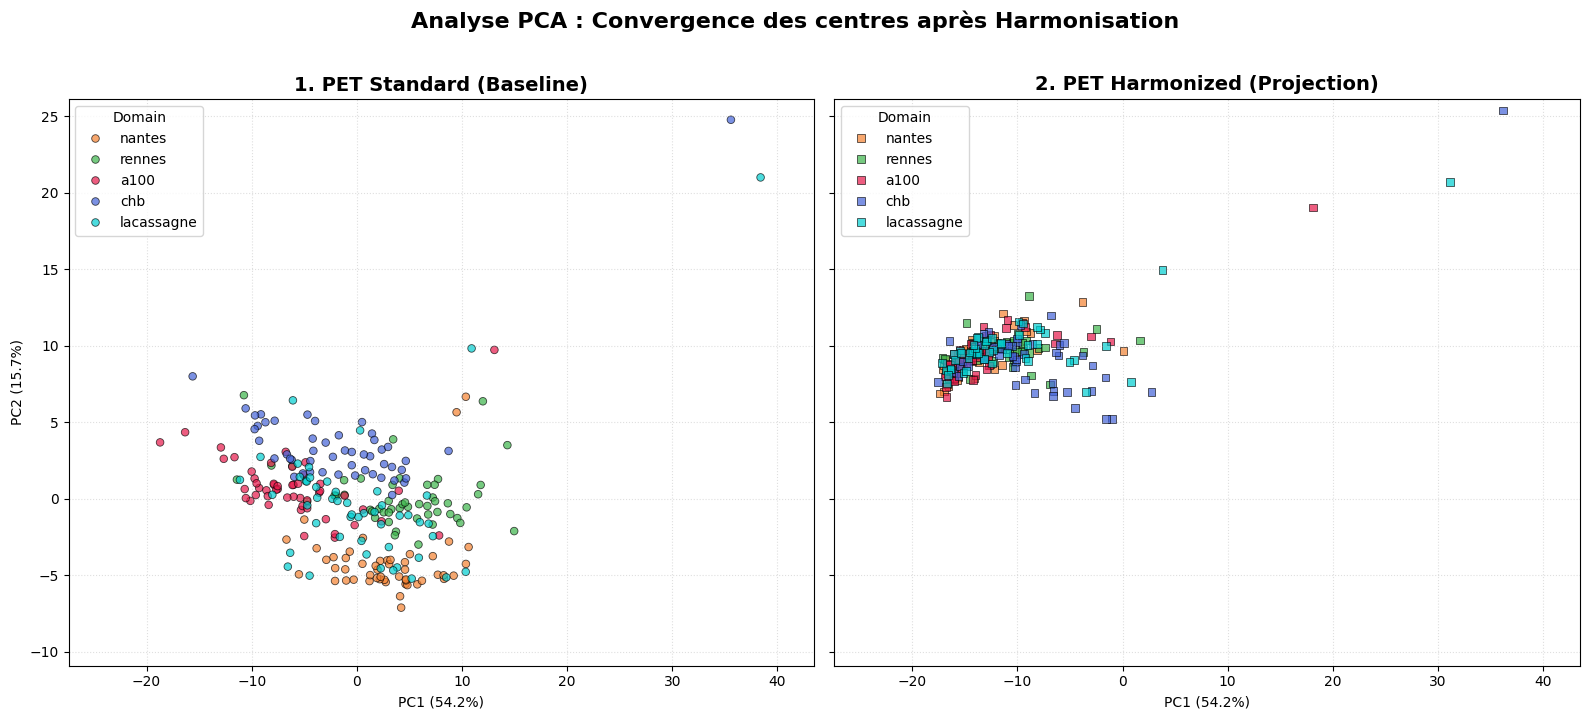

In [104]:
N = 50

voi_master_df = master_df[
    (master_df['VOI'] == 'liver') & 
    (master_df['Domain'].isin(['nantes', 'lacassagne', 'a100', 'rennes', 'chb'])) &
    (master_df['Modality'].isin(['pet', 'harmonized-pet-vae']))
]

df_harm_only = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae']
patients_gardes = df_harm_only.drop_duplicates('Subject_ID').groupby('Domain').head(N)['Subject_ID']

voi_master_df = voi_master_df[voi_master_df['Subject_ID'].isin(patients_gardes)]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae'].copy()

features = df_top['Feature'].tolist()
selected_features = df_top[df_top['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

display_pca(df_std, df_harm, selected_features)

Nombre de features sélectionnées : 93


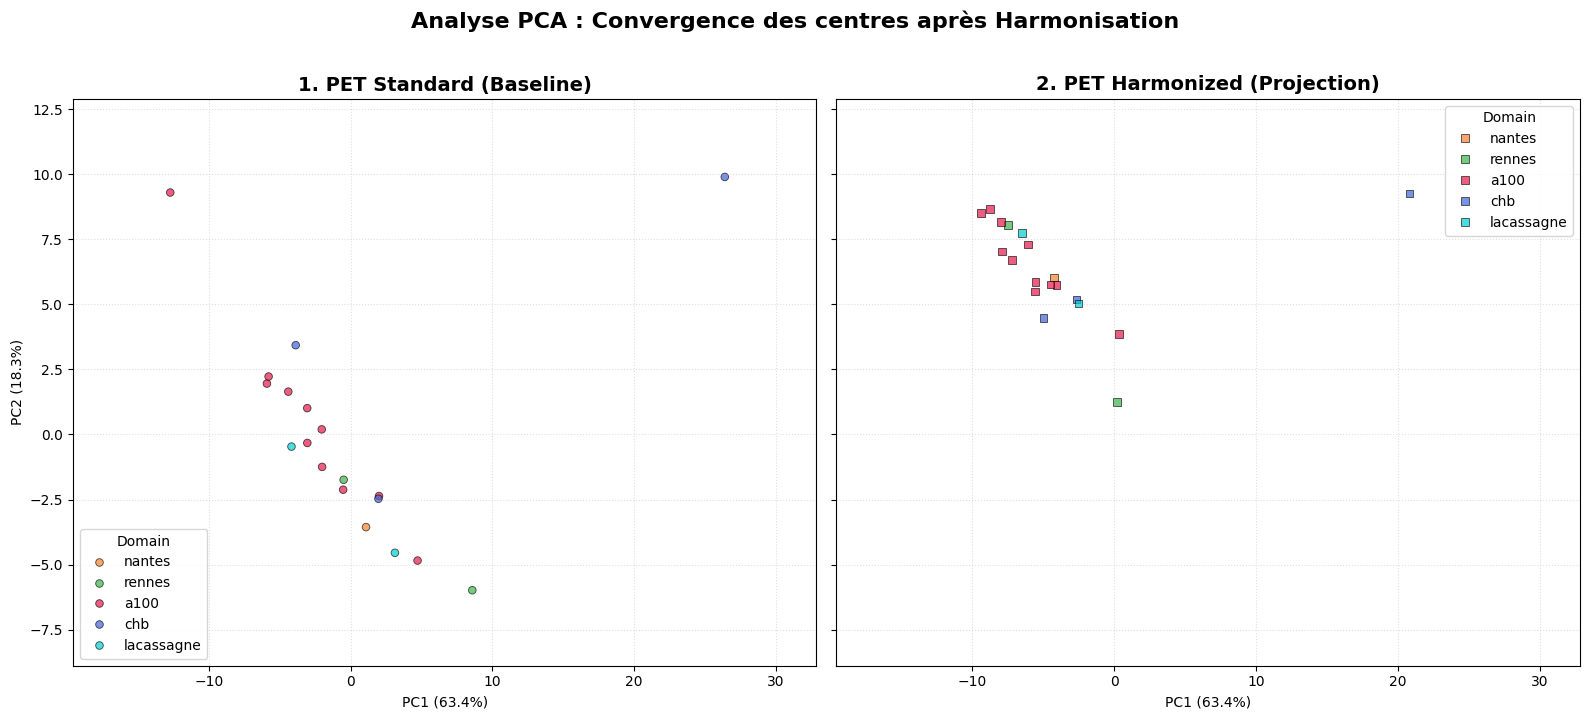

In [6]:
N = 50

voi_master_df = master_df[
    (master_df['VOI'] == 'liver') & 
    (master_df['Domain'].isin(['nantes', 'lacassagne', 'a100', 'rennes', 'chb'])) &
    (master_df['Modality'].isin(['pet', 'harmonized-pet-vae-dual']))
]

df_harm_only = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae-dual']
patients_gardes = df_harm_only.drop_duplicates('Subject_ID').groupby('Domain').head(N)['Subject_ID']

voi_master_df = voi_master_df[voi_master_df['Subject_ID'].isin(patients_gardes)]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae-dual'].copy()

features = df_top['Feature'].tolist()
selected_features = df_top[df_top['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

display_pca(df_std, df_harm, selected_features)

In [ ]:
N = 50

voi_master_df = master_df[
    (master_df['VOI'] == 'liver') & 
    (master_df['Domain'].isin(['nantes', 'lacassagne', 'a100', 'rennes', 'chb'])) &
    (master_df['Modality'].isin(['pet', 'harmonized-pet-vae-dual']))
]

df_harm_only = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae-dual']
patients_gardes = df_harm_only.drop_duplicates('Subject_ID').groupby('Domain').head(N)['Subject_ID']

voi_master_df = voi_master_df[voi_master_df['Subject_ID'].isin(patients_gardes)]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae'].copy()

features = df_top['Feature'].tolist()
selected_features = df_top[df_top['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

display_pca(df_std, df_harm, selected_features)

Nombre de features sélectionnées : 93


/home/aghiles/anaconda3/envs/work_p11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


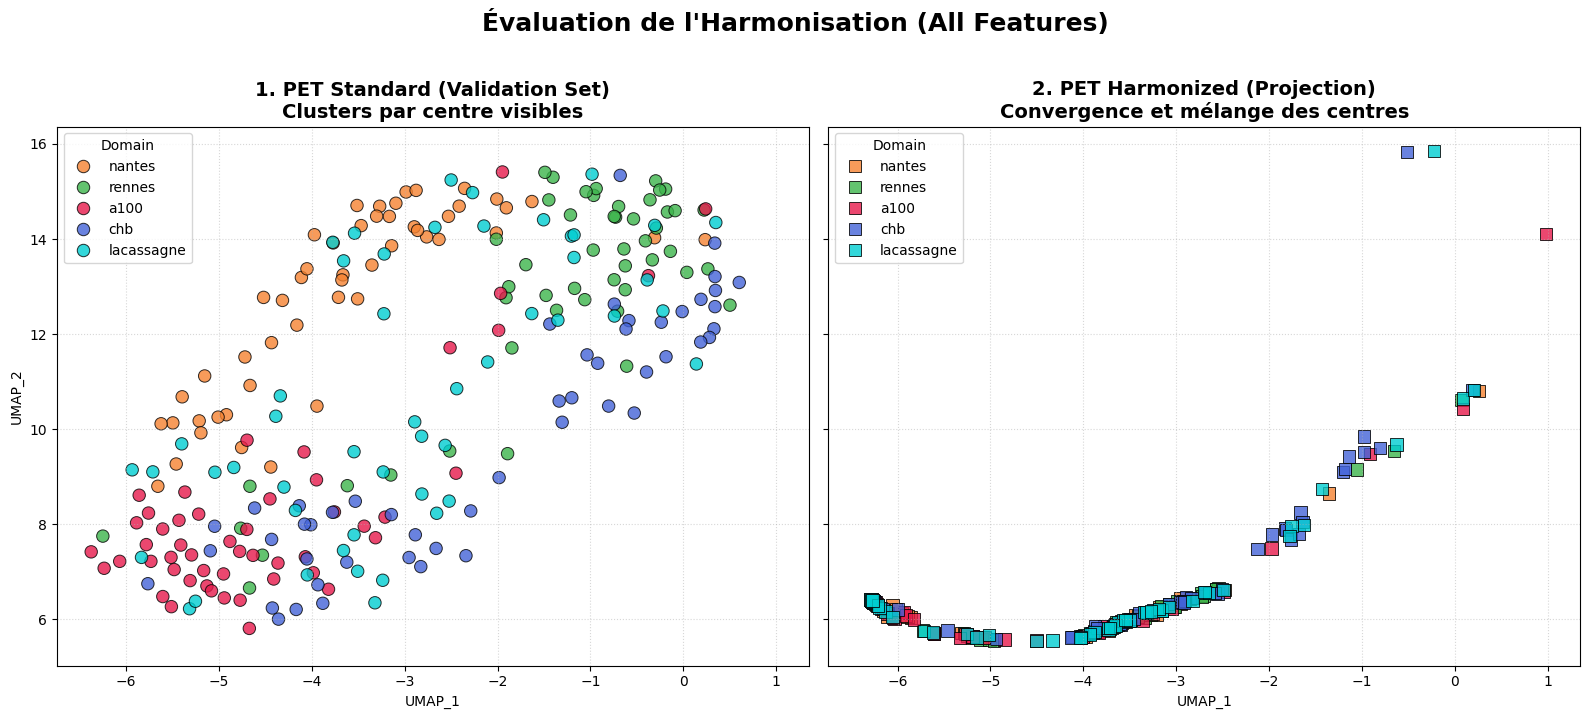

In [112]:
N = 50

voi_master_df = master_df[
    (master_df['VOI'] == 'liver') & 
    (master_df['Domain'].isin(['nantes', 'lacassagne', 'a100', 'rennes', 'chb'])) &
    (master_df['Modality'].isin(['pet', 'harmonized-pet-vae']))
]

df_harm_only = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae']
patients_gardes = df_harm_only.drop_duplicates('Subject_ID').groupby('Domain').head(N)['Subject_ID']

voi_master_df = voi_master_df[voi_master_df['Subject_ID'].isin(patients_gardes)]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae'].copy()

features = df_top['Feature'].tolist()
selected_features = df_top[df_top['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

display_umap(40, 0.5, df_std, df_harm, selected_features)

Nombre de features sélectionnées : 93
Calcul du t-SNE sur 500 points (Perplexity=30)...


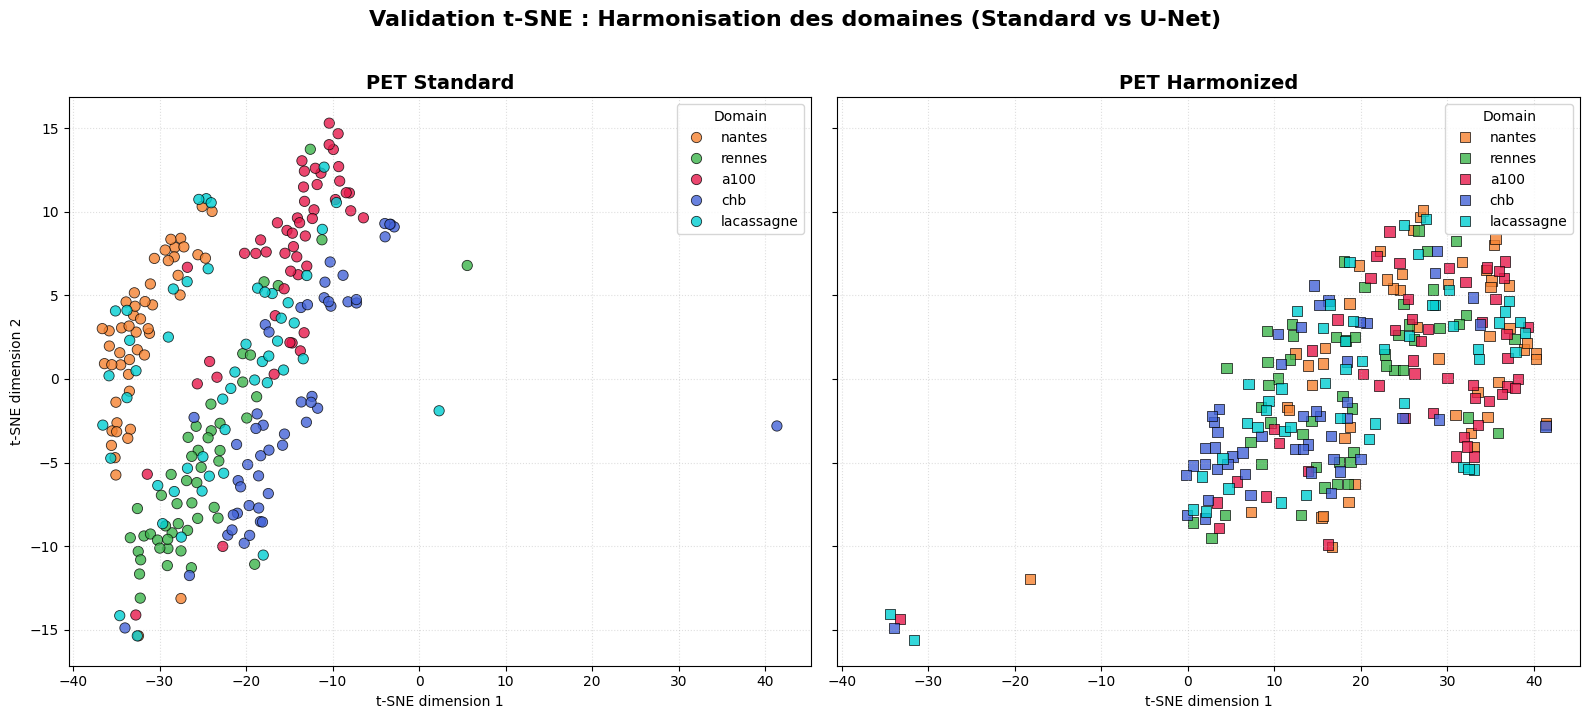

In [113]:
N = 50

voi_master_df = master_df[
    (master_df['VOI'] == 'liver') & 
    (master_df['Domain'].isin(['nantes', 'lacassagne', 'a100', 'rennes', 'chb'])) &
    (master_df['Modality'].isin(['pet', 'harmonized-pet-vae']))
]

df_harm_only = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae']
patients_gardes = df_harm_only.drop_duplicates('Subject_ID').groupby('Domain').head(N)['Subject_ID']

voi_master_df = voi_master_df[voi_master_df['Subject_ID'].isin(patients_gardes)]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae'].copy()

features = df_top['Feature'].tolist()
selected_features = df_top[df_top['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

display_tsne(df_std, df_harm, selected_features)

Nombre de features sélectionnées : 93
Calcul du t-SNE sur 198 points (Perplexity=30)...


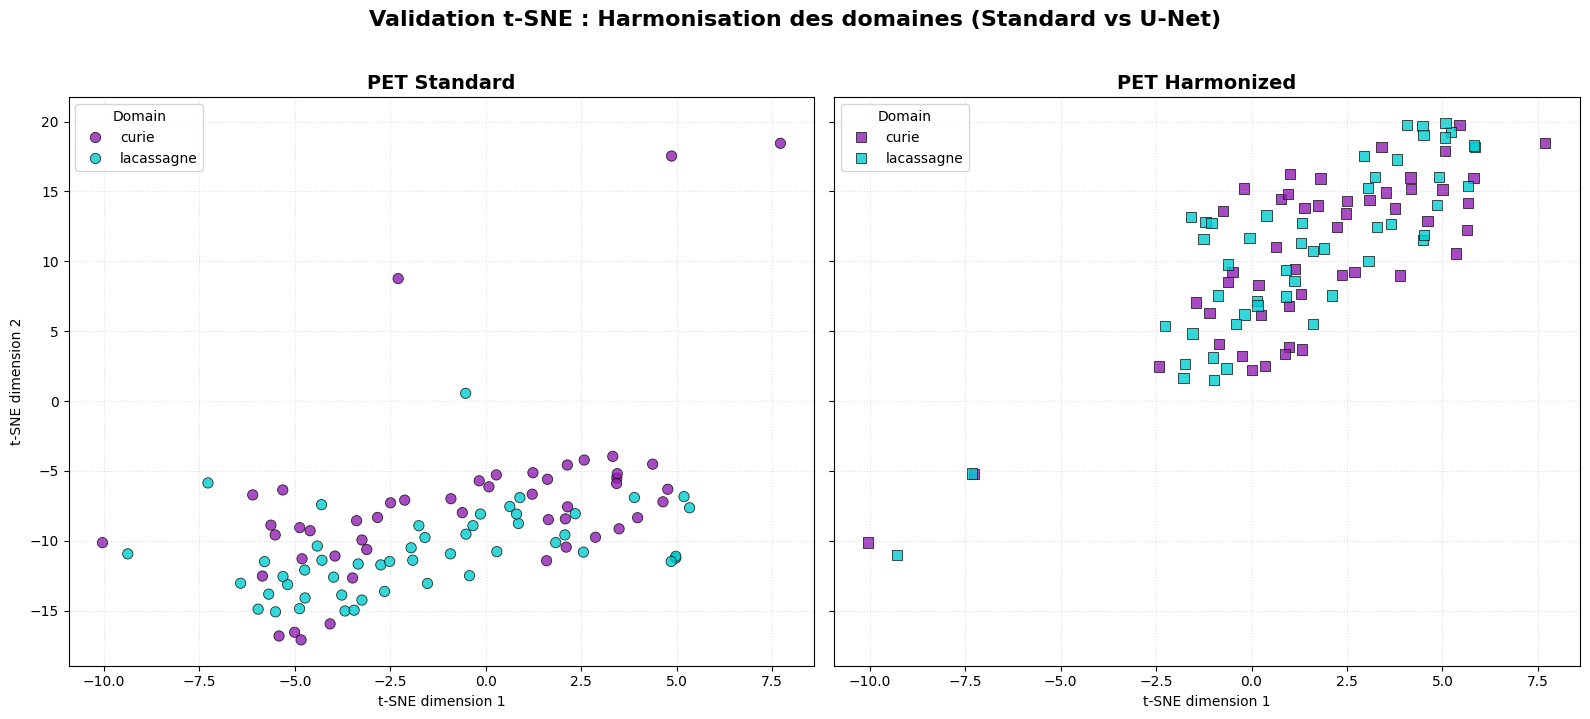

In [114]:
N = 50

voi_master_df = master_df[
    (master_df['VOI'] == 'liver') & 
    (master_df['Domain'].isin(['curie', 'lacassagne'])) &
    (master_df['Modality'].isin(['pet', 'harmonized-pet-vae']))
]

df_harm_only = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae']
patients_gardes = df_harm_only.drop_duplicates('Subject_ID').groupby('Domain').head(N)['Subject_ID']

voi_master_df = voi_master_df[voi_master_df['Subject_ID'].isin(patients_gardes)]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae'].copy()

features = df_top['Feature'].tolist()
selected_features = df_top[df_top['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

display_tsne(df_std, df_harm, selected_features)

In [75]:
features = df_top['Feature'].tolist()

selected_features = df_top[df_top['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

voi_master_df = master_df[(master_df['VOI'] == 'liver') & (master_df['Domain'].isin(['nantes', 'curie', 'rennes']))]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae'].copy()
df_all = pd.concat([df_std, df_harm], ignore_index=True)

# display_cov(df_cov)
df_all['COV'] = np.sqrt(df_all['original_firstorder_Variance']) / df_all['original_firstorder_Mean']
df_all['Entropy'] = df_all['original_firstorder_Entropy']

if 'original_firstorder_InterquartileRange' in df_all.columns and 'original_firstorder_Median' in df_all.columns:
    df_all['Robust_COV'] = df_all['original_firstorder_InterquartileRange'] / df_all['original_firstorder_Median']
else:
    df_all['Robust_COV'] = df_all['original_firstorder_MeanAbsoluteDeviation'] / df_all['original_firstorder_Median']

# --- 3. PRÉPARATION GLOBALE (SANS ÉCHANTILLONNAGE) ---
domains = sorted(df_all['Domain'].unique())
modalities = ['pet', 'harmonized-pet-vae']
metrics = ['COV', 'Entropy', 'Robust_COV']
metric_labels = ['COV ($\sigma / \mu$)', 'Entropie (Complexité)', 'Robust COV ($IQR / Median$)']

# On utilise l'intégralité du DataFrame pour l'affichage
df_plot = df_all.copy()

# Pré-calcul des limites par colonne basées sur les 195 patients (1% / 99%)
column_limits = {}
for met in metrics:
    p1, p99 = np.percentile(df_plot[met].dropna(), [1, 99])
    margin = (p99 - p1) * 0.1
    column_limits[met] = (p1 - margin, p99 + margin)



Nombre de features sélectionnées : 30


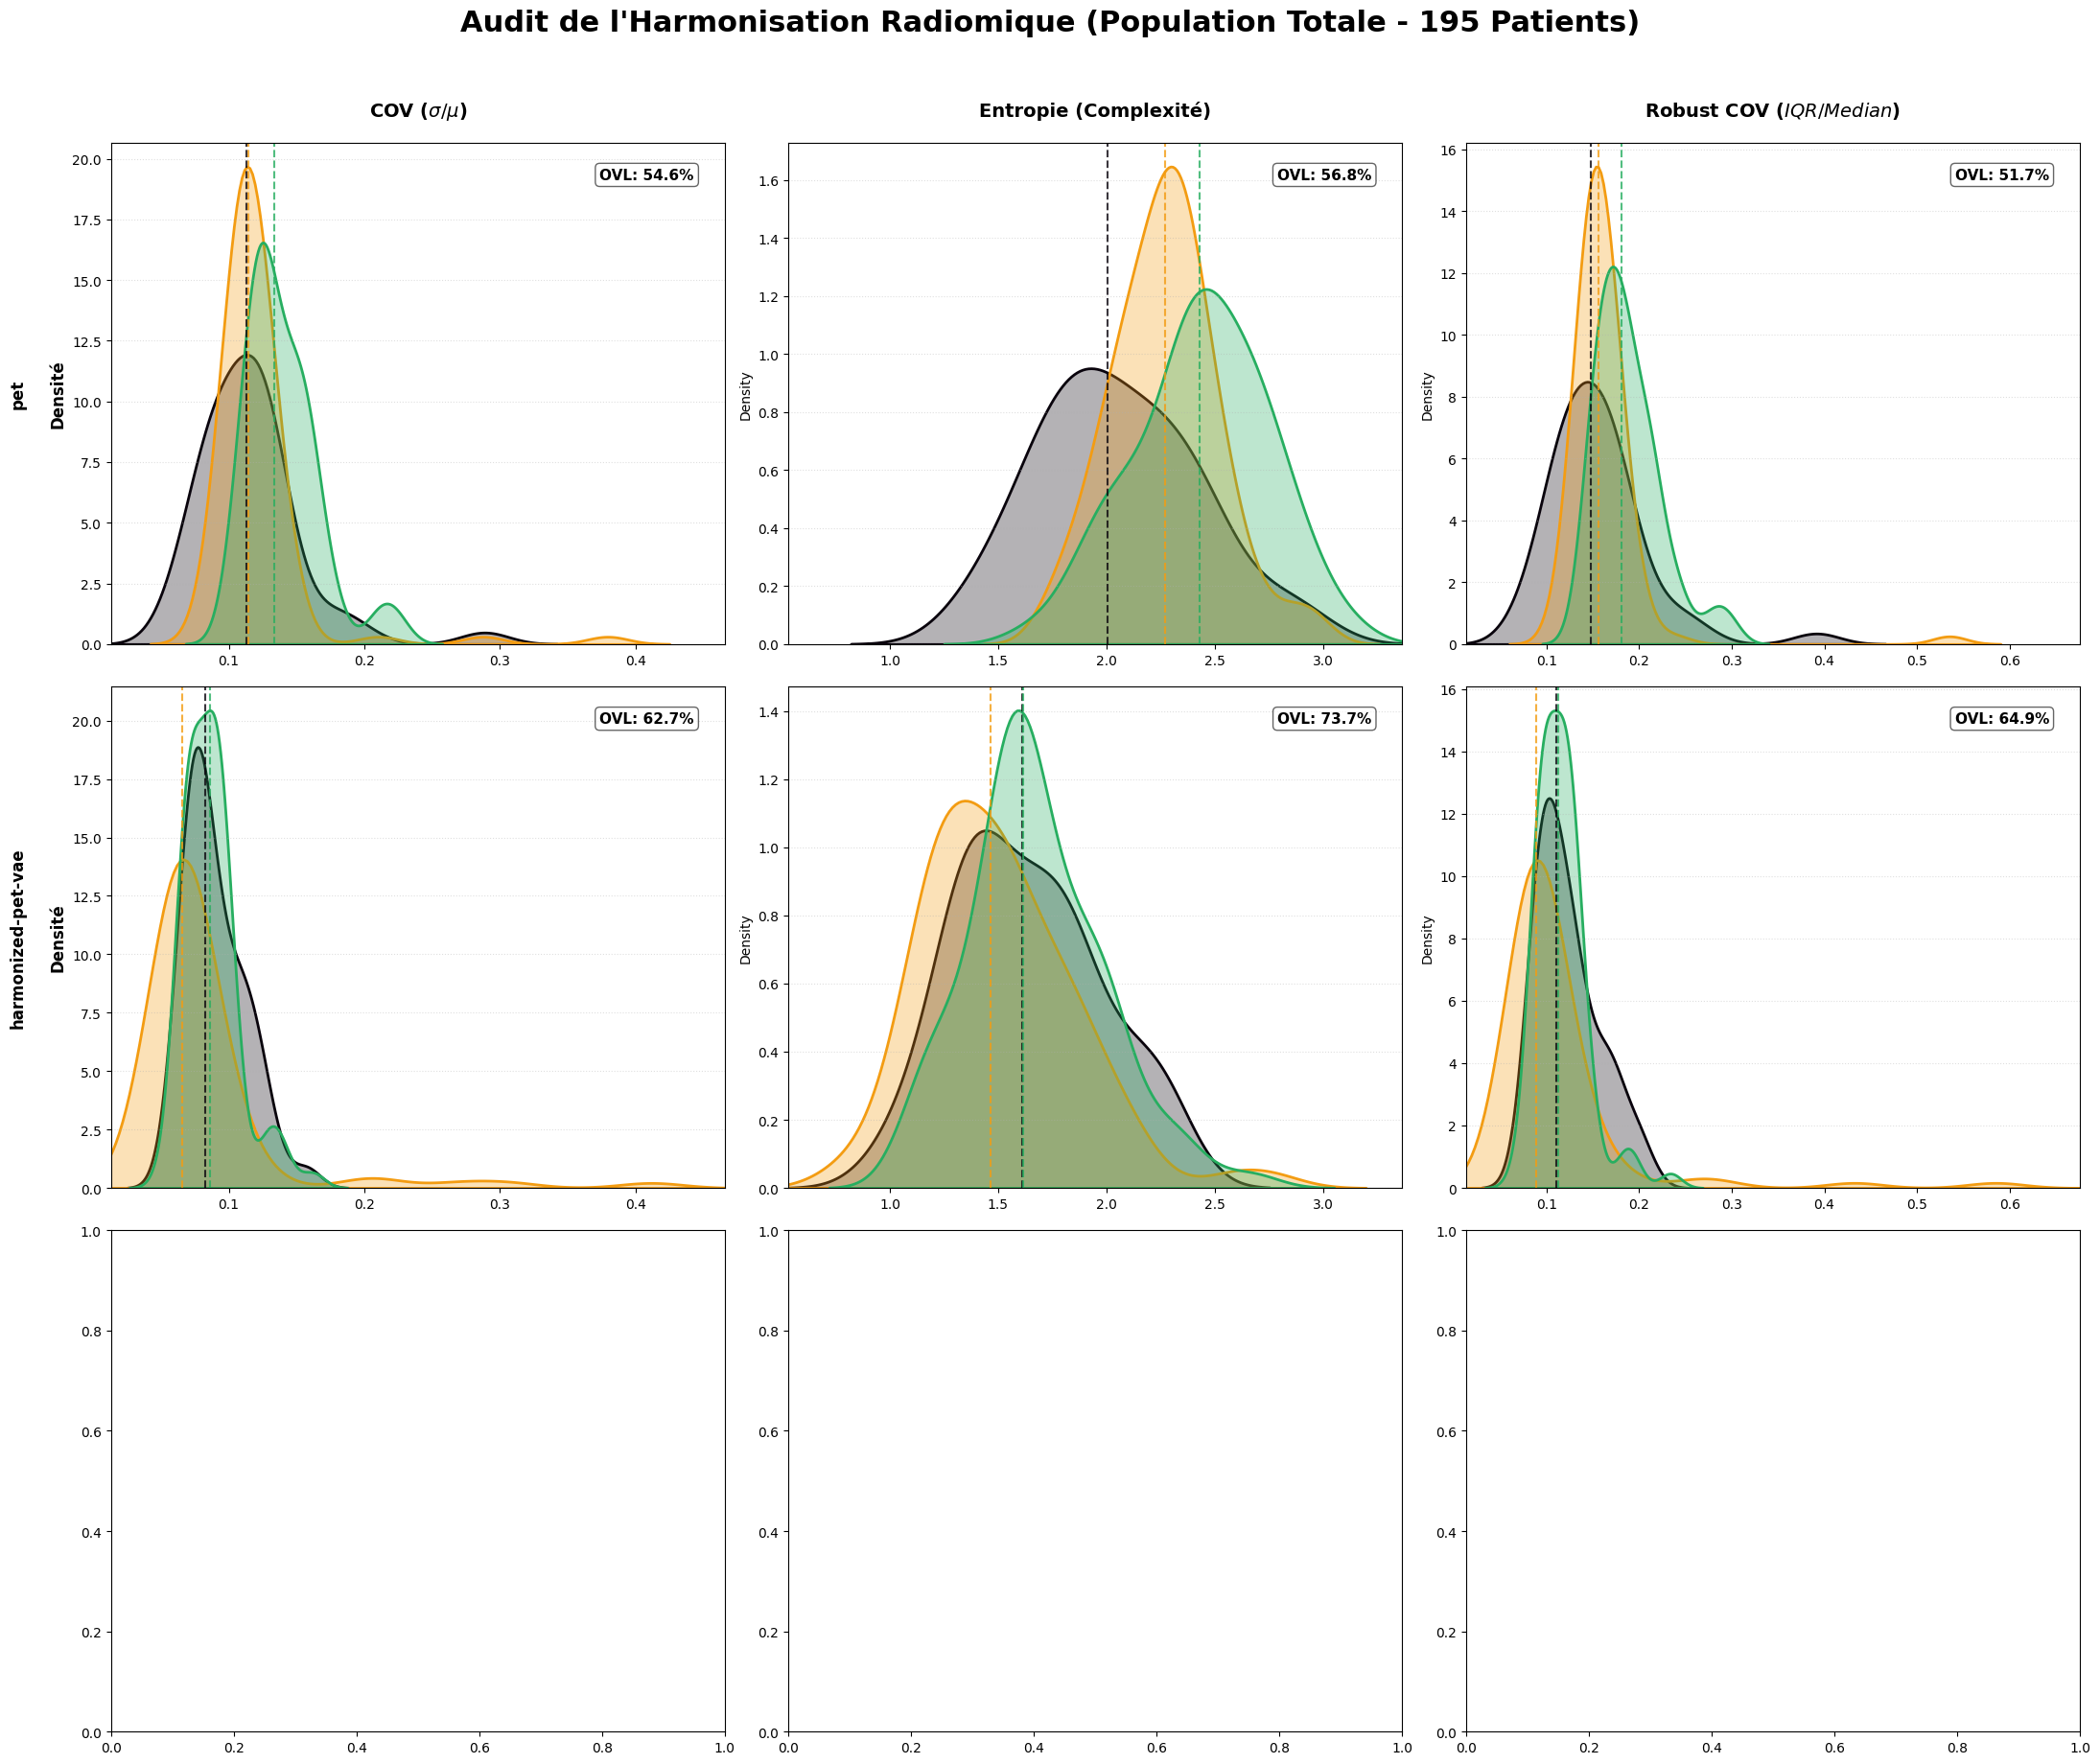

In [76]:
# --- 4. TRACÉ DE LA MATRICE 3x3 ---
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
palette = {
    'a100': '#E74C3C', 
    'chb': '#3498DB', 
    'rennes': '#27AE60', 
    'nice': '#9B59B6',
    'nantes': '#F39C12',
    'curie': "#09030C",
}

for row, mod in enumerate(modalities):
    for col, met in enumerate(metrics):
        ax = axes[row, col]
        df_mod = df_plot[df_plot['Modality'] == mod]
        
        # Bornes globales pour le filtrage des outliers
        p1_global, p99_global = np.percentile(df_plot[met].dropna(), [1, 99])
        
        dist_data = {}
        for d in domains:
            vals = df_mod[df_mod['Domain'] == d][met].dropna().values
            # Filtrage des percentiles extrêmes pour la clarté visuelle
            filtered_vals = vals[(vals >= p1_global) & (vals <= p99_global)]
            if len(filtered_vals) > 0:
                dist_data[d] = filtered_vals

        # Calcul de l'overlap sur la population totale filtrée
        ovl_score = calculate_ovl(dist_data)
        
        # Affichage des courbes KDE
        for d, vals in dist_data.items():
            sns.kdeplot(vals, ax=ax, fill=True, color=palette[d], 
                        label=f"{d} (n={len(vals)})", alpha=0.3, linewidth=2)
            # Ligne verticale sur la Médiane
            ax.axvline(np.median(vals), color=palette[d], linestyle='--', alpha=0.8)
        
        # Verrouillage des axes X par métrique
        ax.set_xlim(column_limits[met])
        
        # Annotations et style
        if col == 0: ax.set_ylabel(f"{mod.replace('_', ' ')}\n\nDensité", fontsize=12, fontweight='bold')
        if row == 0: ax.set_title(metric_labels[col], fontsize=14, pad=20, fontweight='black')
        
        ax.text(0.95, 0.95, f"OVL: {ovl_score:.1f}%", transform=ax.transAxes, 
                ha='right', va='top', fontsize=11, fontweight='bold', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
        
        ax.grid(axis='y', linestyle=':', alpha=0.4)
        if row == 2: ax.set_xlabel(metric_labels[col])

plt.suptitle("Audit de l'Harmonisation Radiomique (Population Totale - 195 Patients)", 
            fontsize=22, y=1.02, fontweight='black')
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.manifold import TSNE

def evaluate_harmonization_clustering(df_std, df_harm, df_features):
    features = df_features['Feature'].tolist()
    
    X_std_raw = df_std[features].values
    X_harm_raw = df_harm[features].values
    
    le = LabelEncoder()
    y_true_std = le.fit_transform(df_std['Domain'])
    y_true_harm = le.transform(df_harm['Domain']) # Même encodeur pour constance
    
    n_centers = len(np.unique(y_true_std))

    # Scaling basé sur le standard
    scaler = StandardScaler()
    X_std_scaled = scaler.fit_transform(X_std_raw)
    X_harm_scaled = scaler.transform(X_harm_raw)

    pca_clus = PCA(n_components=0.95, random_state=42)
    X_std_pca = pca_clus.fit_transform(X_std_scaled)
    X_harm_pca = pca_clus.transform(X_harm_scaled)
    
    print(f"📊 PCA pour clustering : {X_std_pca.shape[1]} composantes retenues (sur {len(features)}) expliquant 95% de la variance.")

    kmeans_std = KMeans(n_clusters=n_centers, random_state=42, n_init=10)
    clusters_std = kmeans_std.fit_predict(X_std_pca)
    
    kmeans_harm = KMeans(n_clusters=n_centers, random_state=42, n_init=10)
    clusters_harm = kmeans_harm.fit_predict(X_harm_pca)

    ari_std = adjusted_rand_score(y_true_std, clusters_std)
    ari_harm = adjusted_rand_score(y_true_harm, clusters_harm)
    
    print(f"🎯 SCORE ARI (Standard)   : {ari_std:.4f} (Proche de 1 = Biais centre fort)")
    print(f"🎯 SCORE ARI (Harmonized) : {ari_harm:.4f} (Proche de 0 = Biais éliminé)")

    print("Calcul du t-SNE pour l'affichage...")
    X_combined = np.vstack((X_std_scaled, X_harm_scaled))
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    tsne_res = tsne.fit_transform(X_combined)
    
    df_std_plot = df_std.copy()
    df_harm_plot = df_harm.copy()
    
    n_std = len(X_std_scaled)
    df_std_plot['TSNE1'], df_std_plot['TSNE2'] = tsne_res[:n_std, 0], tsne_res[:n_std, 1]
    df_harm_plot['TSNE1'], df_harm_plot['TSNE2'] = tsne_res[n_std:, 0], tsne_res[n_std:, 1]
    
    df_std_plot['Cluster'] = [f"Cluster {c}" for c in clusters_std]
    df_harm_plot['Cluster'] = [f"Cluster {c}" for c in clusters_harm]

    # 6. VISUALISATION (Grille 2x2)
    fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True, sharey=True)
    
    palette_true = {
        'a100': '#E6194B', 'chb': '#4363D8', 'rennes': '#3CB44B', 
        'nice': '#F032E6', 'nantes': '#F58231', 'curie': '#911EB4', 'lacassagne': '#00CED1'
    }
    
    # Palette générique pour les Clusters trouvés par l'IA
    palette_cluster = sns.color_palette("tab10", n_centers)

    plots_config = [
        (df_std_plot, 'Domain', palette_true, axes[0,0], "1. Vrais Centres (PET Standard)"),
        (df_std_plot, 'Cluster', palette_cluster, axes[0,1], f"2. Clustering IA (PET Standard) - ARI: {ari_std:.3f}"),
        (df_harm_plot, 'Domain', palette_true, axes[1,0], "3. Vrais Centres (PET Harmonized)"),
        (df_harm_plot, 'Cluster', palette_cluster, axes[1,1], f"4. Clustering IA (PET Harmonized) - ARI: {ari_harm:.3f}")
    ]

    for df, hue_col, pal, ax, title in plots_config:
        sns.scatterplot(
            data=df, x='TSNE1', y='TSNE2', hue=hue_col, 
            palette=pal, ax=ax, s=60, alpha=0.8, edgecolor='black', linewidth=0.5
        )
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.4)
        if hue_col == 'Domain':
            ax.legend(title="Vrai Centre", bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.legend(title="Cluster IA", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.suptitle("Évaluation de l'Harmonisation par Clustering Objectif (K-Means)", fontsize=20, y=1.02, fontweight='black')
    plt.tight_layout()
    plt.show()


Nombre de features sélectionnées : 93
📊 PCA pour clustering : 8 composantes retenues (sur 93) expliquant 95% de la variance.
🎯 SCORE ARI (Standard)   : 0.2240 (Proche de 1 = Biais centre fort)
🎯 SCORE ARI (Harmonized) : 0.0650 (Proche de 0 = Biais éliminé)
Calcul du t-SNE pour l'affichage...


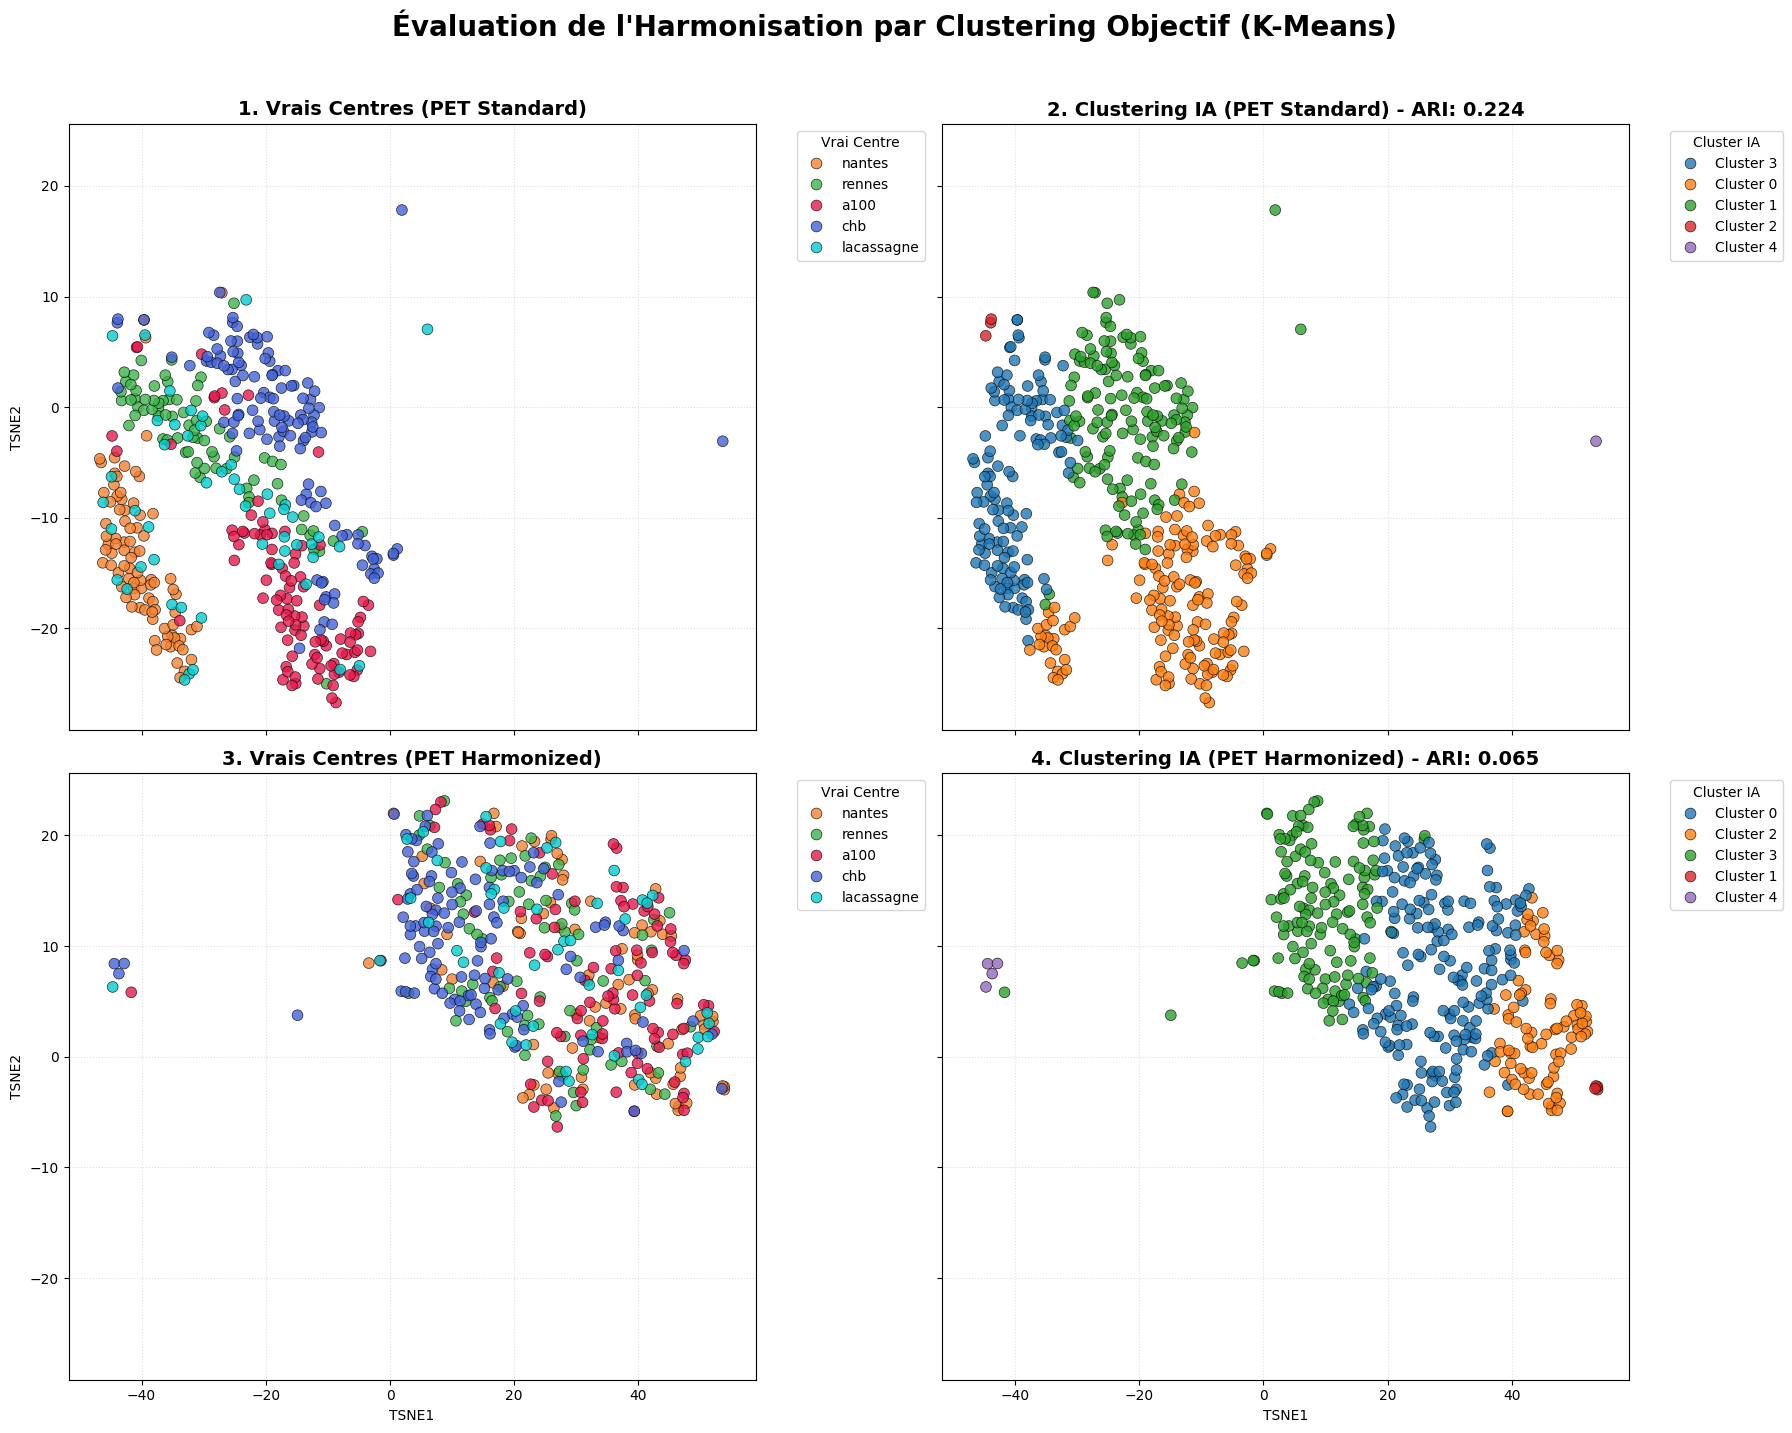

In [9]:
features = df_top['Feature'].tolist()

selected_features = df_top[df_top['Feature'].isin(features)].copy()
print(f"Nombre de features sélectionnées : {len(features)}")

voi_master_df = master_df[(master_df['VOI'] == 'liver') & (master_df['Domain'].isin(['nantes', 'lacassagne', 'rennes', 'a100', 'chb']))]

df_std = voi_master_df[voi_master_df['Modality'] == 'pet'].copy()
df_harm = voi_master_df[voi_master_df['Modality'] == 'harmonized-pet-vae'].copy()

evaluate_harmonization_clustering(df_std, df_harm, selected_features)